# Try the DecoKiller Module

In [1]:
using Revise
using Latexify
using StatsBase
using Plots
using Plots.Measures

includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")
# Utility function for plotting
includet("../julia/src/custom_plots.jl")

ENV["JULIA_DEBUG"] = "DecoKiller"

using .DecoKiller

In [2]:
cfg, state, logs = load_configuration("../configs/config.toml")

@info "Real noise: " cfg.real_noise.name
@info "Current choice of noise: " state.choice.current
@info "Reference recovery state σ:" cfg.sigma
@info "Starting state:" state.ρ0

# Ensure this is a valid, not-pure, state
@info "Eigenvalues: " eigvals(cfg.sigma)
@info "Trace: " tr(cfg.sigma)
@info "Purity: " tr(cfg.sigma * cfg.sigma)

Using specified real noise from config...


┌ Info: Real noise: 
└   cfg.real_noise.name = "amplitude_damping"
┌ Info: Current choice of noise: 
└   state.choice.current = 2
┌ Info: Reference recovery state σ:
│   cfg.sigma =
│    2×2 Matrix{ComplexF64}:
│     0.5+0.0im  0.0+0.0im
└     0.0-0.0im  0.5+0.0im
┌ Info: Starting state:
│   state.ρ0 =
│    2×2 Matrix{ComplexF64}:
│     0.5+0.0im  0.0+0.0im
└     0.0-0.0im  0.5+0.0im
┌ Info: Eigenvalues: 
│   eigvals(cfg.sigma) =
│    2-element Vector{Float64}:
│     0.5
└     0.5
┌ Info: Trace: 
└   tr(cfg.sigma) = 1.0 + 0.0im
┌ Info: Purity: 
└   tr(cfg.sigma * cfg.sigma) = 0.5 + 0.0im


In [3]:
# 1. Apply noise (update rho1 and create intermediate rho2_)
N = state.M_total
N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap
Nx = cfg.real_noise.supermap

@info Nx == N1
@info Nx == N2

ρ_free = unvec(cfg.real_noise.supermap * vec(state.ρ0))
ρ_rec_ = unvec(Nx * vec(state.ρ0))
ρ1 = unvec(N1 * vec(state.ρ0))
ρ2 = unvec(N2 * vec(state.ρ0))
ρ_rec_

[ Info: true
[ Info: false


2×2 Matrix{ComplexF64}:
 0.590635+0.0im       0.0+0.0im
      0.0+0.0im  0.409365+0.0im

In [4]:
# 2. Recovery
model = CollisionModel(N, cfg.sigma)
ρ_rec, η = apply_collision(model, ρ_rec_)
model1 = CollisionModel(N1, cfg.sigma)
ρ1, η1 = apply_collision(model, ρ1)
model2 = CollisionModel(N2, cfg.sigma)
ρ2, η2 = apply_collision(model, ρ2)


# 3. Logging
fid_initial = fidelity(state.ρ0, ρ_rec)
fid_ref = fidelity(cfg.sigma, ρ_rec)
fid_track = fidelity(state.ρ0, ρ_free)

@info "Fidelity wrt initial state: " fid_initial
@info "Fidelity wrt reference state: " fid_ref
@info "Fidelity of free evolution: " fid_track

┌ Info: Fidelity wrt initial state: 
└   fid_initial = 0.9998495208684097
┌ Info: Fidelity wrt reference state: 
└   fid_ref = 0.9998495208684097
┌ Info: Fidelity of free evolution: 
└   fid_track = 0.9917167528466782


In [5]:
w = discrimin(η, η1, η2)
@info "Probabilities of the POVM outputs:" w

povm = sample(cfg.rng, [1, 2], Weights(w))
@info "Measurement result:" povm


┌ Info: Probabilities of the POVM outputs:
│   w =
│    2-element Vector{Float64}:
│     0.5
└     0.5
┌ Info: Measurement result:
└   povm = 1


In [6]:
# Update the remaining state variables
if povm == 1
    append!(state.choice.c1, 1)
    append!(state.choice.c2, 0)
    state.choice.c1_count += 1
elseif povm == 2
    append!(state.choice.c1, 0)
    append!(state.choice.c2, 1)
    state.choice.c2_count += 1
end

inertia = 2
diff = state.choice.c1_count - state.choice.c2_count

if state.choice.current == 1
    if diff < -inertia
        state.choice.current = 2
    end
else
    if diff > inertia
        state.choice.current = 1
    end
end

@info "Updated choice: " state.choice.current
@info state.noise_options[state.choice.current].name

# Now we build the Petz on the belief that the noise was always that of the current choice
omega = state.noise_options[state.choice.current].supermap_noise
chosen_model = CollisionModel(state.noise_options[state.choice.current].supermap, cfg.sigma)
P = kraus_to_superop(model.kraus_rec);

┌ Info: Updated choice: 
└   state.choice.current = 2
[ Info: bitflip


In [7]:
# Update noises
state.M_total = omega * P * state.M_total
N1 = state.noise_options[1].supermap_noise * P * N1
N2 = state.noise_options[2].supermap_noise * P * N2
# Update the truth
Nx = cfg.real_noise.supermap * P * Nx 

@info Nx == N1
@info Nx == N2

[ Info: true
[ Info: false


## Reset and add the temporal loop

Using specified real noise from config...


[ Info: Real noise: bitflip
[ Info: Current choice of noise: amplitude_damping
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice = 1
┌ Info: Updated choice: 
└   new_choice =

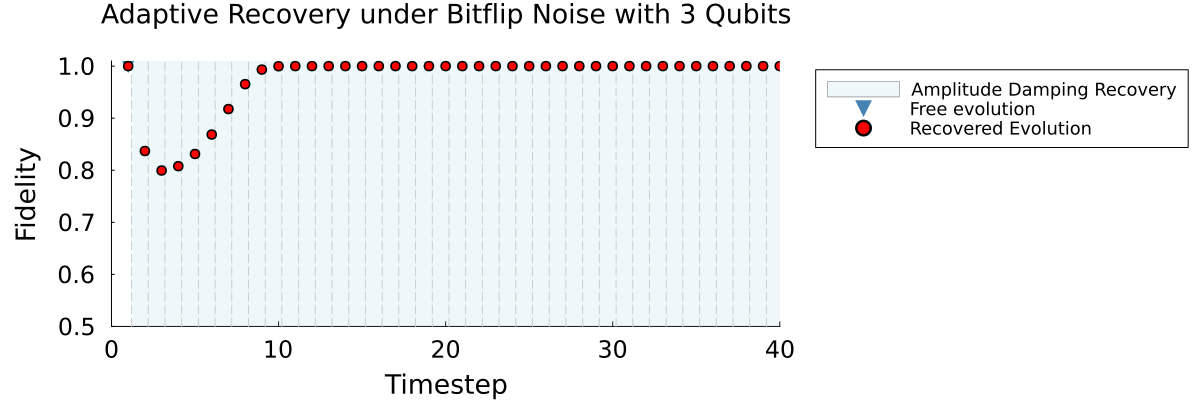

In [40]:

cfg, state, logs = load_configuration("../configs/config.toml");

# Change variable names for brevity
Ox = cfg.real_noise.supermap
O1 = state.noise_options[1].supermap
O2 = state.noise_options[2].supermap
N_free = cfg.real_noise.supermap
N = state.M_total
N1 = O1
N2 = O2
Nx = Ox

@info "Real noise: $(cfg.real_noise.name)"
@info "Current choice of noise: $(state.noise_options[state.choice.current].name)"
@debug "Reference recovery state σ: $(cfg.sigma)"
@debug "Starting state: $(ρ0=state.ρ0)"

variables = []

for n in 1:cfg.n_timesteps
    
    # 1. Apply noise (create intermediate rho_ before recovery)
    ρ_free = unvec(N_free * vec(state.ρ0))
    ρ_rec_ = unvec(Nx * vec(state.ρ0))
    ρ1 = unvec(N1 * vec(state.ρ0))
    ρ2 = unvec(N2 * vec(state.ρ0))
    
    # 2. Recovery
    model = CollisionModel(state.choice.current == 1 ? N1 : N2, cfg.sigma)
    P = kraus_to_superop(model.kraus_rec);

    ρ_rec, η = apply_collision(model, ρ_rec_)
    model1 = CollisionModel(N1, cfg.sigma)
    ρ1, η1 = apply_collision(model1, ρ1)
    model2 = CollisionModel(N2, cfg.sigma)
    ρ2, η2 = apply_collision(model2, ρ2)
	
	
    # 4. Measuring Fildelity and Logging
    fid_initial = fidelity(state.ρ0, ρ_rec)
    fid_track = fidelity(state.ρ0, ρ_free)
	
    @debug "Fidelity wrt initial state: $(fidelity_recovery=fid_initial)"
    @debug "Fidelity of free evolution: $(fidelity_free=fid_track)"
    
    push!(logs.ref_fidelities, fid_track)
    push!(logs.fidelities, fid_initial)
    
    # 5. Update noises for the next iteration
    push!(variables, [Nx, N1, N2, P])  # save superoperators at current step
    Nx = cfg.real_noise.supermap * P * Nx
    N1 = O1 * P * N1
    N2 = O2 * P * N2
    N_free = cfg.real_noise.supermap * N_free
	
    # 6. Compare output ancillas
	# First, we extend the ancillas dimensionality
	max_d_ancillas = 4^cfg.n_qubits
	η, η1, η2 = [embed_state(ancilla, max_d_ancillas) for ancilla in (η, η1, η2)]
	# and normalize them with the probabilities of their respective noise channels
	η1 = state.noise_options[1].probability * η1
	η2 = state.noise_options[2].probability * η2
    w = discrimin(η, η1, η2)
    @debug "Probabilities of the POVM outputs: $w"

    povm = sample(cfg.rng, [1, 2], Weights(w))
    @debug "Measurement result: $povm"

    # 7. Update guess for the next iteration
    if povm == 1
        append!(state.choice.c1, 1)
        append!(state.choice.c2, 0)
        state.choice.c1_count += 1
    elseif povm == 2
        append!(state.choice.c1, 0)
        append!(state.choice.c2, 1)
        state.choice.c2_count += 1
    end

    inertia = 1
    diff = state.choice.c1_count - state.choice.c2_count

    # The previous-step choice changes only if there is enough inertia in the opposing choice
    # Positive `diff` means that c1 is leading, negative means that c2 is leading
    if state.choice.current == 1
        if diff < -inertia
            state.choice.current = 2
        end
    else
        if diff > inertia
            state.choice.current = 1
        end
    end
	append!(state.choice.current_choices, state.choice.current)

    @info "Updated choice: " new_choice=state.choice.current
    
end

plot_autorecovery(state, cfg, logs; ylims=[0.5, 1.01])

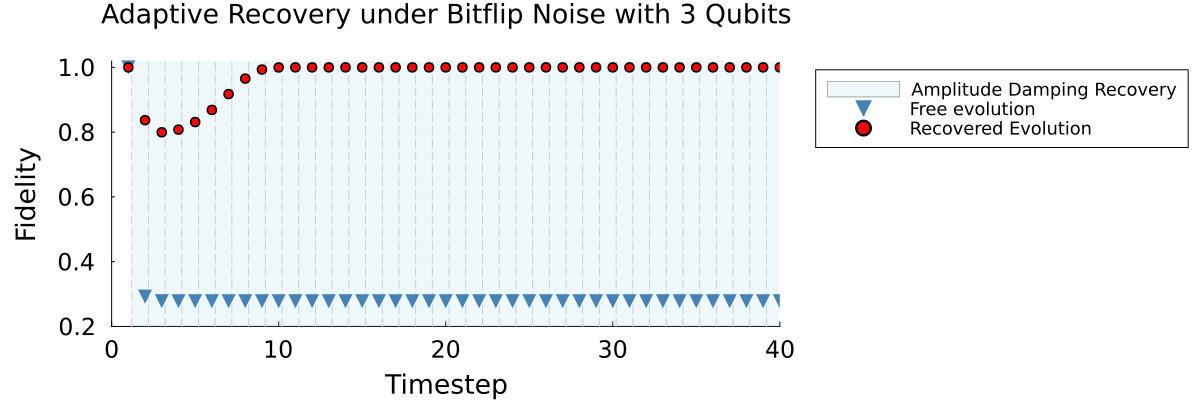

In [41]:
plot_autorecovery(state, cfg, logs; ylims=[0.2, 1.02])

In [10]:
Nxs = [v[1] for v in variables]
N1s = [v[2] for v in variables]
N2s = [v[3] for v in variables]
Ps = [v[4] for v in variables]

display(latexify(N1s[20]))
display(latexify(N2s[20]))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5906346212165979+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.590634621216598+0.0\mathit{i} \\
0.0\mathit{i} & 0.06766764136116936+0.0\mathit{i} & 0.06766764136116936+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.06766764136116936+0.0\mathit{i} & 0.06766764136116936+0.0\mathit{i} & 0.0\mathit{i} \\
0.4093653749834028+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.40936537498340286+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.4999999981000013+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999981000014+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999981000012+0.0\mathit{i} & 0.4999999981000012+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999981000012+0.0\mathit{i} & 0.4999999981000012+0.0\mathit{i} & 0.0\mathit{i} \\
0.49999999810000134+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999810000145+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

In [11]:
# Suppose we want to recover Noise 2 (true noise)
display(latexify(chop!(N2s[8])))
# What state do this maps to?
ρ = unvec(N2s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")
model = CollisionModel(N2s[8], cfg.sigma)
P = kraus_to_superop(model.kraus_rec);
display(latexify(chop!(P)))
# What does the recovery do?
ρ = unvec(P * N2s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")

L"\begin{equation}
\left[
\begin{array}{cccc}
0.49999999930000033+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999930000044+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999993000004+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.4999999993000004+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.49999999930000044+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.49999999860000083 + 0.0im"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.49999999989999994+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999999000001+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999990000027+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.49999999920000043+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999992000006+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.49999999840000103 + 0.0im"

In [12]:
# Insted, if we were to recover Noise 1 (wrong noise)
display(latexify(chop!(N1s[8])))
# What state do this maps to?
ρ = unvec(N1s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")
model = CollisionModel(N1s[8], cfg.sigma)
P = kraus_to_superop(model.kraus_rec);
display(latexify(chop!(P)))
# What does the recovery do?
ρ = unvec(P * N1s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5906346226341206+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.5906346226341208+0.0\mathit{i} \\
0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.0\mathit{i} \\
0.4093653759658794+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4093653759658796+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.5906346226341207+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4093653759658795+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.5164292684938361 + 0.0im"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.4999999999153453+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999998778596+0.0\mathit{i} \\
0.0\mathit{i} & 0.22844908243567985+0.0\mathit{i} & 0.22844908243568005+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.22844908243568005+0.0\mathit{i} & 0.22844908243567985+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999999153455+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999998778599+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.49999999920000004+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999992000003+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.49999999840000037 + 0.0im"

## Follow the Evolution

In [14]:
Nxs = [v[1] for v in variables]
N1s = [v[2] for v in variables]
N2s = [v[3] for v in variables]
Ps = [v[4] for v in variables]

# Simulate step 1
N_free = Nxs[1]
ρ_free = unvec(N_free * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[1] * vec(state.ρ0))
ρ_rec = unvec(Ps[1] * vec(ρ_rec_))


fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[1] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.9917167528466782
Fidelity after recovery:	 0.9998495208684095


In [15]:
# Step 2
step = 2
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Na
Fidelity of free evolution:	 0.9720463769467086
Fidelity after recovery:	 0.9999999373228509


In [16]:
# Step 3
step = 3
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.9462143712039793
Fidelity after recovery:	 0.9999999993999946


In [17]:
# Step 4
step = 4
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.917361177590761
Fidelity after recovery:	 0.9999999992000004


In [18]:
# Step 5
step = 5
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.8874350265226002
Fidelity after recovery:	 0.9999999990000004


In [19]:
# Step 6
step = 6
ρ_free = unvec((N_free)^step * vec(state.ρ0))
ρ_rec_ = unvec(Nxs[step] * vec(state.ρ0))
ρ_rec = unvec(Ps[step] * vec(ρ_rec_))

fid_track = fidelity(state.ρ0, ρ_free)
fid_rec = fidelity(state.ρ0, ρ_rec)

choice = state.choice.c1[step] == 1 ? "Na" : "Nb"
println("Choice of noise to recover:\t $choice")
println("Fidelity of free evolution:\t $fid_track")
println("Fidelity after recovery:\t $fid_rec")

Choice of noise to recover:	 Nb
Fidelity of free evolution:	 0.8576557250118441
Fidelity after recovery:	 0.9999999988000003


In [20]:
first_change = findfirst(x -> x == 1, state.choice.current_choices)
display(latexify(chop!(Ps[first_change - 1])))
display(latexify(chop!(Ps[first_change])))
display(latexify(chop!(Ps[first_change + 1])))

MethodError: MethodError: no method matching -(::Nothing, ::Int64)
The function `-` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  -(!Matched::Base.CoreLogging.LogLevel, ::Integer)
   @ Base logging/logging.jl:133
  -(!Matched::BigFloat, ::Union{Int16, Int32, Int64, Int8})
   @ Base mpfr.jl:553
  -(!Matched::Missing, ::Number)
   @ Base missing.jl:123
  ...


In [21]:
display(latexify(N1s[1]))
display(latexify(N2s[1]))

L"\begin{equation}
\left[
\begin{array}{cccc}
1.0+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.18126924692201815+0.0\mathit{i} \\
0.0\mathit{i} & 0.9048374180359595+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.9048374180359595+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.8187307530779817+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5676676416183064+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4323323583816936+0.0\mathit{i} \\
0.0\mathit{i} & 0.5676676416183064+0.0\mathit{i} & 0.4323323583816936+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4323323583816936+0.0\mathit{i} & 0.5676676416183064+0.0\mathit{i} & 0.0\mathit{i} \\
0.4323323583816936+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.5676676416183064+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

In [22]:
# Suppose we want to recover Noise 2 (true noise)
display(latexify(chop!(N2s[8])))
# What state do this maps to?
ρ = unvec(N2s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")
model = CollisionModel(N2s[8], cfg.sigma)
P = kraus_to_superop(model.kraus_rec);
display(latexify(chop!(P)))
# What does the recovery do?
ρ = unvec(P * N2s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")

L"\begin{equation}
\left[
\begin{array}{cccc}
0.49999999930000033+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999930000044+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999993000004+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999993000005+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.4999999993000004+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.49999999930000044+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.49999999860000083 + 0.0im"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.49999999989999994+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999999000001+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999990000027+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.49999999920000043+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999992000006+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.49999999840000103 + 0.0im"

In [23]:
# Insted, if we were to recover Noise 1 (wrong noise)
display(latexify(chop!(N1s[8])))
# What state do this maps to?
ρ = unvec(N1s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")
model = CollisionModel(N1s[8], cfg.sigma)
P = kraus_to_superop(model.kraus_rec);
display(latexify(chop!(P)))
# What does the recovery do?
ρ = unvec(P * N1s[8] * vec(state.ρ0))
display(latexify(chop!(ρ)))
display("Purity: $(tr(ρ * ρ))")

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5906346226341206+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.5906346226341208+0.0\mathit{i} \\
0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.2246644817440806+0.0\mathit{i} & 0.0\mathit{i} \\
0.4093653759658794+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4093653759658796+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.5906346226341207+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4093653759658795+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.5164292684938361 + 0.0im"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.4999999999153453+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999998778596+0.0\mathit{i} \\
0.0\mathit{i} & 0.22844908243567985+0.0\mathit{i} & 0.22844908243568005+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.22844908243568005+0.0\mathit{i} & 0.22844908243567985+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999999153455+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999998778599+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.49999999920000004+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999992000003+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

"Purity: 0.49999999840000037 + 0.0im"

In [24]:
display(latexify(Ps[1]))
display(latexify(Ps[2]))
display(latexify(Ps[3]))
display(latexify(Ps[4]))
display(latexify(Ps[5]))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5676676415047727+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4323323582952273+0.0\mathit{i} \\
0.0\mathit{i} & 0.5676676415047729+0.0\mathit{i} & 0.4323323582952273+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4323323582952273+0.0\mathit{i} & 0.5676676415047729+0.0\mathit{i} & 0.0\mathit{i} \\
0.4323323582952273+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.567667641504773+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5012393759880852+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4987606238119148+0.0\mathit{i} \\
0.0\mathit{i} & 0.5012393759880853+0.0\mathit{i} & 0.49876062381191477+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.49876062381191477+0.0\mathit{i} & 0.5012393759880853+0.0\mathit{i} & 0.0\mathit{i} \\
0.49876062381191466+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.5012393759880855+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.5000004156643593+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999995841356403+0.0\mathit{i} \\
0.0\mathit{i} & 0.5000004156643596+0.0\mathit{i} & 0.4999995841356406+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999995841356406+0.0\mathit{i} & 0.5000004156643596+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999995841356409+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.5000004156643599+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.49999999990004657+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999989995314+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999999000468+0.0\mathit{i} & 0.4999999998999533+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999998999533+0.0\mathit{i} & 0.4999999999000468+0.0\mathit{i} & 0.0\mathit{i} \\
0.4999999998999535+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.49999999990004707+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.49999999989999994+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} \\
0.0\mathit{i} & 0.4999999999+0.0\mathit{i} & 0.49999999990000016+0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.49999999990000016+0.0\mathit{i} & 0.4999999999+0.0\mathit{i} & 0.0\mathit{i} \\
0.49999999990000027+0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.4999999999000001+0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"